In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the MNIST dataset
train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

train_images = train_df.iloc[:, 1:].values.astype(np.float32) / 255.0
test_images = test_df.iloc[:, 1:].values.astype(np.float32) / 255.0

train_images = train_images.reshape(-1, 1, 28, 28)
test_images = test_images.reshape(-1, 1, 28, 28)

train_tensor = torch.tensor(train_images)
test_tensor = torch.tensor(test_images)

train_dataset = torch.utils.data.TensorDataset(train_tensor, torch.zeros(len(train_tensor)))
test_dataset = torch.utils.data.TensorDataset(test_tensor, torch.zeros(len(test_tensor)))

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=10, shuffle=False)

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, N):
        super(Autoencoder, self).__init__()
        
        # Encoder: 784 -> 128 -> 64 -> N
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, N)
        )
        
        # Decoder: N -> 64 -> 128 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(N, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Flatten the image
        x = x.view(-1, 784)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        # Reshape back to image dimensions
        return x_hat.view(-1, 1, 28, 28)

In [9]:
def train_autoencoder(N, epochs=30):
    print(f"--- Training Autoencoder with Bottleneck N={N} ---")
    model = Autoencoder(N).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    loss_history = []
    
    for epoch in range(epochs):
        train_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            
        train_loss = train_loss / len(train_loader.dataset)
        loss_history.append(train_loss)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Reconstruction Loss: {train_loss:.4f}")
            
    return model, loss_history

In [ ]:
epochs_to_train = 30

model_n2, loss_n2 = train_autoencoder(N=2, epochs=epochs_to_train)
print("\n")
model_nn32, loss_n32 = train_autoencoder(N=32, epochs=epochs_to_train)

--- Training Autoencoder with Bottleneck N=2 ---
Epoch [1/30], Reconstruction Loss: 0.0654
Epoch [5/30], Reconstruction Loss: 0.0434
Epoch [10/30], Reconstruction Loss: 0.0402
Epoch [15/30], Reconstruction Loss: 0.0387
Epoch [20/30], Reconstruction Loss: 0.0378
Epoch [25/30], Reconstruction Loss: 0.0373
Epoch [30/30], Reconstruction Loss: 0.0369


--- Training Autoencoder with Bottleneck N=32 ---
Epoch [1/30], Reconstruction Loss: 0.0620
Epoch [5/30], Reconstruction Loss: 0.0187
Epoch [10/30], Reconstruction Loss: 0.0135
Epoch [15/30], Reconstruction Loss: 0.0111
Epoch [20/30], Reconstruction Loss: 0.0097
Epoch [25/30], Reconstruction Loss: 0.0087
Epoch [30/30], Reconstruction Loss: 0.0080


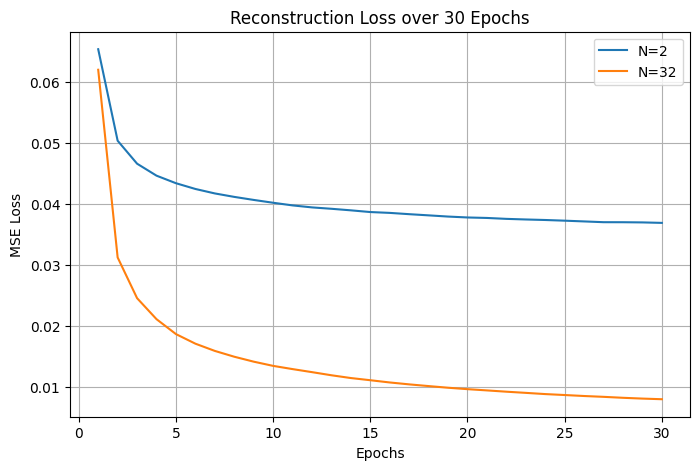

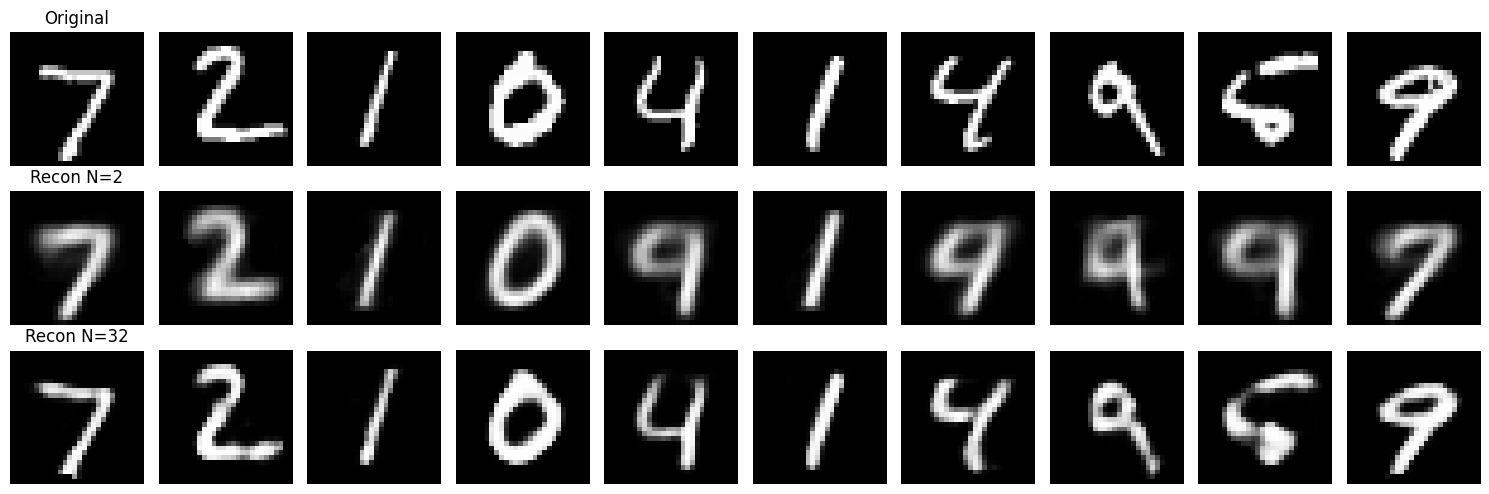

In [ ]:
# Plot 1: Reconstruction Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_to_train + 1), loss_n2, label='N=2')
plt.plot(range(1, epochs_to_train + 1), loss_n32, label='N=32')
plt.title('Reconstruction Loss over 30 Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Original vs Reconstructed Images
model_n2.eval()
model_nn32.eval()

dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images.to(device)

with torch.no_grad():
    recon_n2 = model_n2(images).cpu()
    recon_n32 = model_nn32(images).cpu()

images = images.cpu()

# Plotting
fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(15, 5))

for i in range(10):
    axes[0, i].imshow(images[i][0], cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original")
    
    # Reconstructed N=2
    axes[1, i].imshow(recon_n2[i][0], cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Recon N=2")
    
    # Reconstructed N=32
    axes[2, i].imshow(recon_n32[i][0], cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Recon N=32")

plt.tight_layout()
plt.show()